**Deep Learning-Based Detection of AI-Generated Images using Transfer Learning and Explainable AI**

Model: MobileNetV2
Dataset: 140K Real and Fake Faces Dataset

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

2026-03-14 05:33:00.938473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773466381.120411      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773466381.173186      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773466381.596701      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773466381.596760      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773466381.596764      55 computation_placer.cc:177] computation placer alr

In [15]:
import os

# List all directories in /kaggle/input
print(os.listdir("/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"))

['valid', 'test', 'train']


In [17]:
train_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train"
val_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid"
test_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test"

In [19]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

In [20]:
classes = os.listdir(train_dir)
print("Classes:", classes)

Classes: ['fake', 'real']


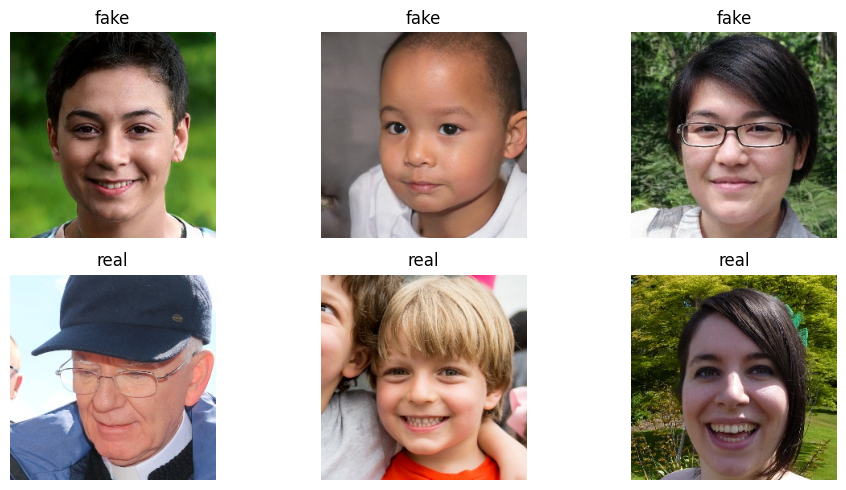

In [21]:
# Number of images to display per class
num_images = 3

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    images = os.listdir(cls_path)
    selected_images = random.sample(images, num_images)
    
    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        plt.subplot(len(classes), num_images, i*num_images + j + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(cls)
plt.tight_layout()
plt.show()

{'fake': 50000, 'real': 50000}


<Axes: title={'center': 'Number of images per class'}>

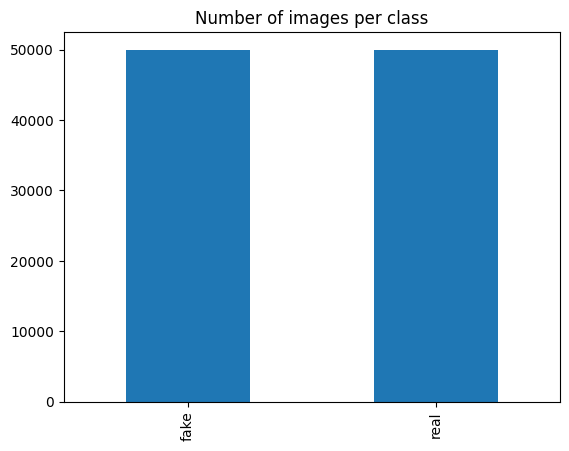

In [22]:
import pandas as pd

train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}
print(train_counts)

# Optional: bar plot
pd.Series(train_counts).plot(kind='bar', title="Number of images per class")

In [23]:
sample_img = mpimg.imread(os.path.join(train_dir, classes[0], os.listdir(os.path.join(train_dir, classes[0]))[0]))
print("Sample image shape:", sample_img.shape)

Sample image shape: (256, 256, 3)


DATA PREPROCESSING

In [18]:
train_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 100000 images belonging to 2 classes.


In [28]:
# Validation generator
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

# Test generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [24]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

I0000 00:00:1773467674.808964      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [30]:

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 293s 94ms/step - accuracy: 0.8560 - loss: 0.3293 - val_accuracy: 0.8539 - val_loss: 0.3356
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 279s 89ms/step - accuracy: 0.8738 - loss: 0.2971 - val_accuracy: 0.8587 - val_loss: 0.3282
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 290s 93ms/step - accuracy: 0.8875 - loss: 0.2666 - val_accuracy: 0.8584 - val_loss: 0.3279
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 290s 93ms/step - accuracy: 0.8960 - loss: 0.2466 - val_accuracy: 0.8696 - val_loss: 0.3150
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 281s 90ms/step - accuracy: 0.9032 - loss: 0.2294 - val_accuracy: 0.8659 - val_loss: 0.3162
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 288s 92ms/step - accuracy: 0.9155 - loss: 0.2045 - val_accuracy: 0.8727 - val_loss: 0.3158
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 286s 91ms/step - accuracy: 0.9225 - loss: 0.1904 - val_accuracy: 0.8695 - val_loss: 0.3210
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 290s 93ms/step - accuracy: 

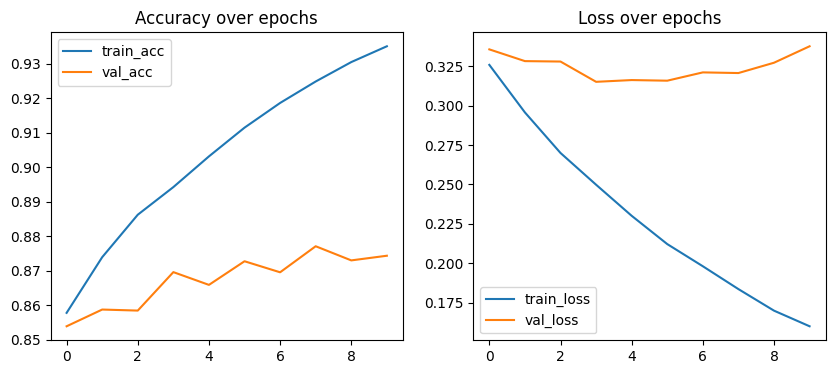

In [31]:
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Accuracy over epochs")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss over epochs")
plt.legend()

plt.show()

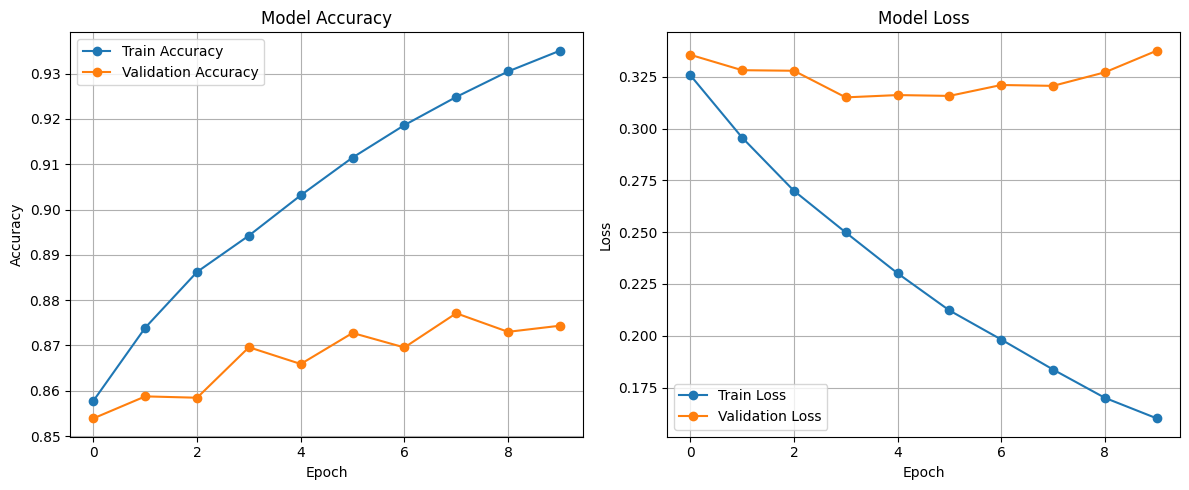

In [33]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy and loss
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("/kaggle/working/accuracy_plot.png")


# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("/kaggle/working/loss_plot.png")


plt.tight_layout()
plt.show()

In [36]:
# Save in native Keras format
model.save("/kaggle/working/final_model.keras")
print("Model saved as final_model.keras")

Model saved as final_model.keras


In [37]:
from tensorflow.keras.models import load_model

# Load model
model = load_model("/kaggle/working/final_model.keras")
print("Model loaded successfully")

Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [41]:
# Save model again in working directory
model.save("/kaggle/working/final_model.keras")
print("Model saved to /kaggle/working/final_model.keras")

Model saved to /kaggle/working/final_model.keras


In [42]:
import os
print(os.listdir("/kaggle/working/"))

['.virtual_documents', 'final_model.keras', 'accuracy_plot.png', 'loss_plot.png', 'final_model.h5']


In [38]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 219s 343ms/step - accuracy: 0.8892 - loss: 0.3001
Test Accuracy: 0.8787500262260437


In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict all test images
y_pred = model.predict(test_generator)
y_pred_classes = np.where(y_pred > 0.5, 1, 0)
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices.keys()))

625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 74ms/step
[[8933 1067]
 [1358 8642]]
              precision    recall  f1-score   support

        fake       0.87      0.89      0.88     10000
        real       0.89      0.86      0.88     10000

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



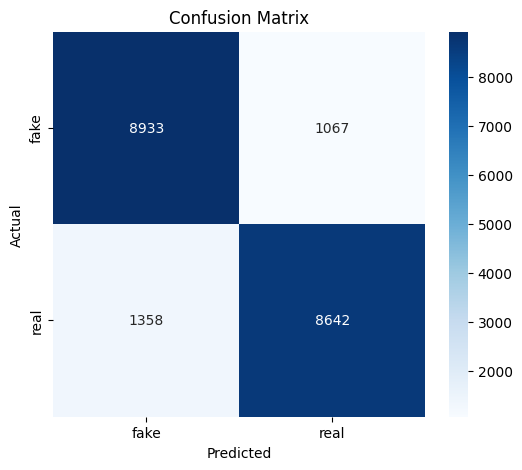

<Figure size 640x480 with 0 Axes>

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_true and y_pred_classes are already defined:
# y_true = test_generator.classes
# y_pred_classes = np.where(model.predict(test_generator) > 0.5, 1, 0)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
plt.savefig("/kaggle/working/confusion_matrix.png")

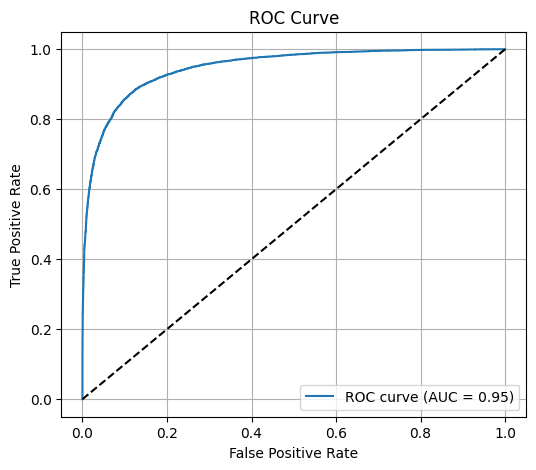

<Figure size 640x480 with 0 Axes>

In [48]:
from sklearn.metrics import roc_curve, auc

y_scores = y_pred  # predicted probabilities

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
plt.savefig("/kaggle/working/ROC_curve.png")

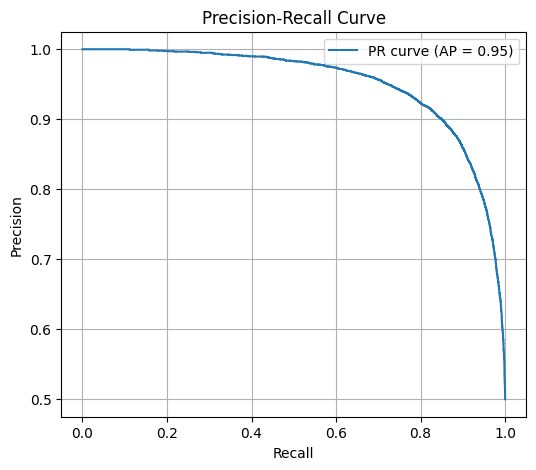

In [49]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
ap_score = average_precision_score(y_true, y_scores)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

**GRADCAM**

In [50]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

In [51]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer
    # and the output predictions
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Compute gradient of top predicted class (or specified) w.r.t last conv layer output
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # Compute gradients
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Pool gradients over all axes
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    
    # Multiply each channel in feature map by pooled gradient
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [68]:
import cv2

def overlay_heatmap(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize heatmap to image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    
    # Overlay
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)
    
    return superimposed_img

In [ ]:

superimposed_img = cv2.addWeighted(img_path, 0.6, heatmap, 0.4, 0)
superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

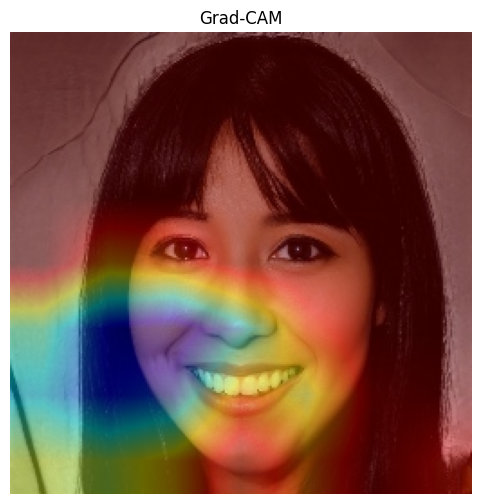

<Figure size 640x480 with 0 Axes>

In [71]:
# Path to image (can be external too)
img_path = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/fake/34JDONPL94.jpg"

# Preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Last conv layer of MobileNetV2
last_conv_layer_name = "Conv_1"  # replace with actual last conv layer if different

# Generate heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Overlay heatmap on original image
superimposed_img = overlay_heatmap(img_path, heatmap)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(superimposed_img)
plt.axis('off')
plt.title("Grad-CAM")
plt.show()
plt.savefig("/kaggle/working/gradcam_fake.png")

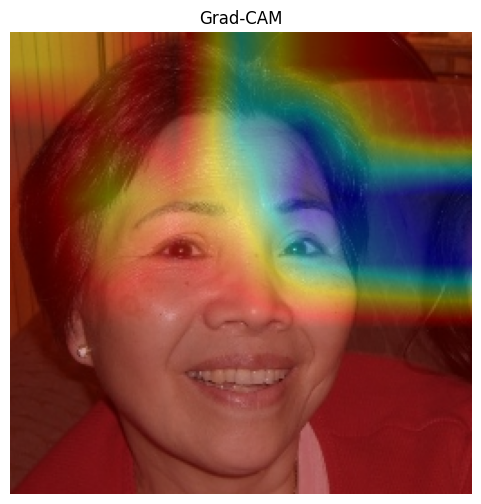

<Figure size 640x480 with 0 Axes>

In [73]:
img_path = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/real/59454.jpg"

# Preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Last conv layer of MobileNetV2
last_conv_layer_name = "Conv_1"  # replace with actual last conv layer if different

# Generate heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Overlay heatmap on original image
superimposed_img = overlay_heatmap(img_path, heatmap)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(superimposed_img)
plt.axis('off')
plt.title("Grad-CAM")
plt.show()
plt.savefig("/kaggle/working/gradcam_real.png")

In [56]:
import os

# Path to your test folder
test_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test"

# List class subfolders
classes = os.listdir(test_dir)
print("Classes:", classes)

Classes: ['fake', 'real']


In [57]:
for cls in classes:
    cls_path = os.path.join(test_dir, cls)
    images = os.listdir(cls_path)
    print(f"\nClass '{cls}' has {len(images)} images. Sample names:")
    print(images[:10])  # show first 10 filenames


Class 'fake' has 10000 images. Sample names:
['DAOH5G9O0Z.jpg', 'IPZTUVD9OS.jpg', '8L0KA3MXPC.jpg', 'UU38CFFH24.jpg', 'G88GNSJ3YI.jpg', '851IXC4FEH.jpg', 'O2MT16VSNV.jpg', 'PI2RRDSUIM.jpg', '34JDONPL94.jpg', '02NUKFGPSJ.jpg']

Class 'real' has 10000 images. Sample names:
['52876.jpg', '59454.jpg', '53932.jpg', '52203.jpg', '28578.jpg', '22288.jpg', '54415.jpg', '00767.jpg', '59221.jpg', '20529.jpg']


In [78]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to test or validation folder
test_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid"

# Create test generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Predict
y_pred_prob = model.predict(test_generator)
y_pred_classes = np.where(y_pred_prob > 0.5, 1, 0)
y_true = test_generator.classes

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_classes))
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))

Found 20000 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step
Confusion Matrix:
 [[8866 1134]
 [1379 8621]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88     10000
           1       0.88      0.86      0.87     10000

    accuracy                           0.87     20000
   macro avg       0.87      0.87      0.87     20000
weighted avg       0.87      0.87      0.87     20000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


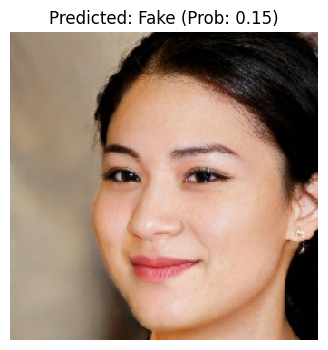

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


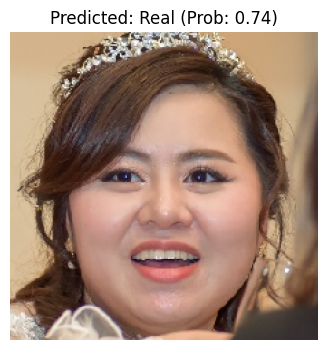

In [80]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# --- Pick class folders ---
test_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test"
classes = os.listdir(test_dir)  # ['fake', 'real']

# Map indices to class names
class_labels = {0: 'fake', 1: 'real'}

# Pick a few sample images (1 from each class)
sample_images = []
for cls in classes:
    cls_path = os.path.join(test_dir, cls)
    imgs = os.listdir(cls_path)
    sample_images.append(os.path.join(cls_path, imgs[0]))  # first image of each class

# --- Predict on each sample image ---
for img_path in sample_images:
    # Load and preprocess
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict probability
    pred_prob = model.predict(img_array)[0][0]
    pred_class = "Real" if pred_prob > 0.5 else "Fake"
    
    # Plot original image with prediction
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {pred_class} (Prob: {pred_prob:.2f})")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


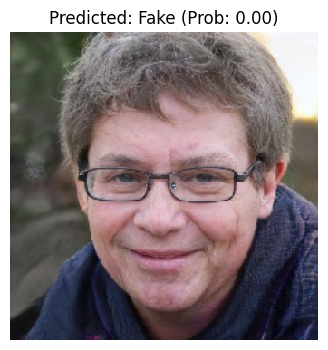

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


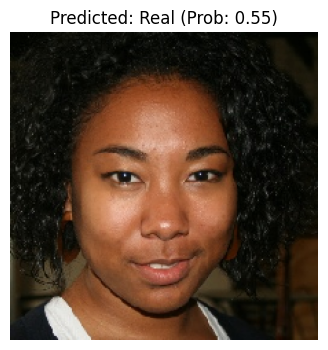

In [97]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# --- Pick class folders ---
test_dir = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid"
classes = os.listdir(test_dir)  # ['fake', 'real']

# Map indices to class names
class_labels = {0: 'fake', 1: 'real'}

# Pick a few sample images (1 from each class)
sample_images = []
for cls in classes:
    cls_path = os.path.join(test_dir, cls)
    imgs = os.listdir(cls_path)
    sample_images.append(os.path.join(cls_path, imgs[5]))  # first image of each class

# --- Predict on each sample image ---
for img_path in sample_images:
    # Load and preprocess
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict probability
    pred_prob = model.predict(img_array)[0][0]
    pred_class = "Real" if pred_prob > 0.5 else "Fake"
    
    # Plot original image with prediction
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {pred_class} (Prob: {pred_prob:.2f})")
    plt.show()

**TESTING EXTERNAL IMAGES**

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import cv2

# --- Path to external image ---
external_img_path = "/kaggle/input/datasets/anetphilomina/test-real/00002.png"  # replace with your file

# --- Load and preprocess image ---
img = image.load_img(external_img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# --- Predict with model ---
pred_prob = model.predict(img_array)[0][0]
pred_class = "Real" if pred_prob > 0.5 else "Fake"
print(f"Predicted class: {pred_class} (probability: {pred_prob:.2f})")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted class: Real (probability: 1.00)


In [116]:
import cv2
import numpy as np

def overlay_heatmap(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize original image to 224x224 (or your model input size)
    img = cv2.resize(img, (224, 224))
    
    # Ensure heatmap is same size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, colormap)
    
    # Overlay
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    
    return img, superimposed_img

In [117]:
original_img, gradcam_img = overlay_heatmap(external_img_path, heatmap)

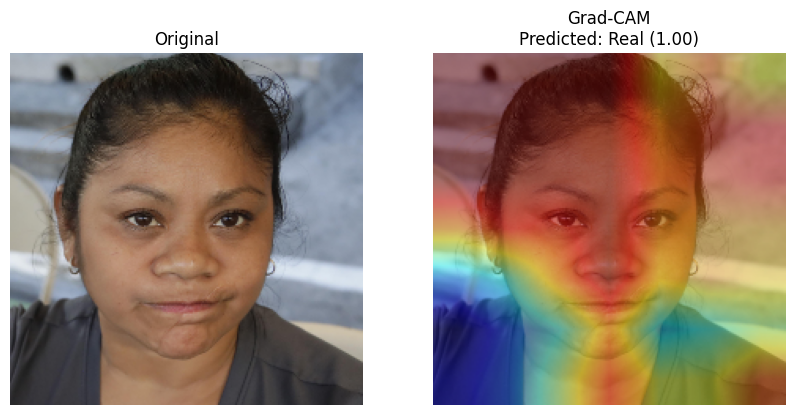

<Figure size 640x480 with 0 Axes>

In [118]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.axis('off')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(gradcam_img)
plt.axis('off')
plt.title(f"Grad-CAM\nPredicted: {pred_class} ({pred_prob:.2f})")
plt.show()
plt.savefig("/kaggle/working/test_real_gradcam.png")

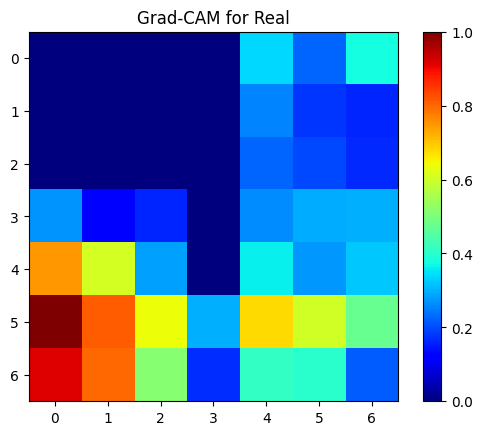

In [120]:
# Plot raw heatmap
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title(f"Grad-CAM for {pred_class}")
plt.show()

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import cv2

# --- Path to external image ---
external_img_path = "/kaggle/input/datasets/anetphilomina/test-fake/download (22).jfif"  # replace with your file

# --- Load and preprocess image ---
img = image.load_img(external_img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# --- Predict with model ---
pred_prob = model.predict(img_array)[0][0]
pred_class = "Real" if pred_prob > 0.5 else "Fake"
print(f"Predicted class: {pred_class} (probability: {pred_prob:.2f})")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted class: Fake (probability: 0.03)


In [109]:
import cv2
import numpy as np

def overlay_heatmap(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    # Load original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize original image to 224x224 (or your model input size)
    img = cv2.resize(img, (224, 224))
    
    # Ensure heatmap is same size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, colormap)
    
    # Overlay
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    
    return img, superimposed_img

In [110]:
original_img, gradcam_img = overlay_heatmap(external_img_path, heatmap)

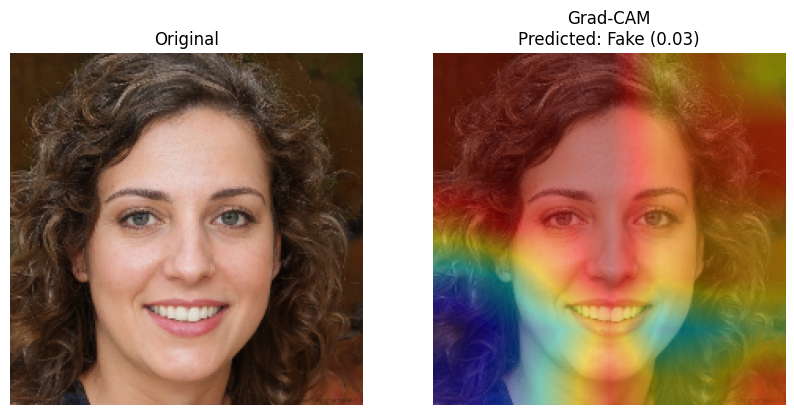

<Figure size 640x480 with 0 Axes>

In [113]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_img)
plt.axis('off')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(gradcam_img)
plt.axis('off')
plt.title(f"Grad-CAM\nPredicted: {pred_class} ({pred_prob:.2f})")
plt.show()
plt.savefig("/kaggle/working/test_fake_gradcam.png")

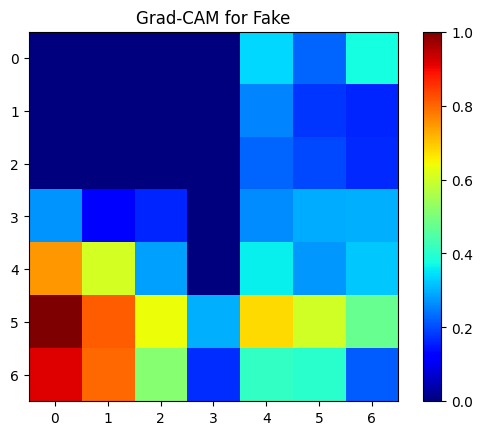

In [112]:
# Plot raw heatmap
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title(f"Grad-CAM for {pred_class}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


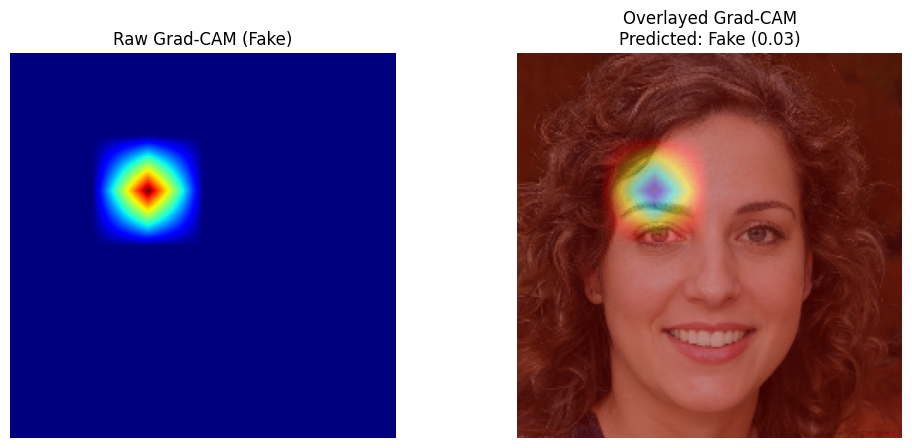

In [127]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- Function to create Grad-CAM heatmap ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps input to conv outputs + predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)

    # Normalize heatmap to 0-1 per image
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-8
    heatmap = heatmap.numpy()

    # Resize heatmap to match input image size (224x224)
    heatmap = cv2.resize(heatmap, (224,224))
    return heatmap, tf.argmax(predictions[0]).numpy()

# --- Function to overlay heatmap on original image ---
def overlay_heatmap(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    
    return img, superimposed_img

# --- External image path ---
external_img_path = "/kaggle/input/datasets/anetphilomina/test-fake/download (22).jfif"  # replace with your image

# --- Load and preprocess ---
img = tf.keras.utils.load_img(external_img_path, target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# --- Choose earlier conv layer for better detail ---
last_conv_layer_name = "block_13_depthwise"  # higher resolution layer than last conv

# --- Generate Grad-CAM ---
heatmap, pred_class_idx = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
pred_class = "Real" if pred_class_idx==1 else "Fake"
pred_prob = model.predict(img_array)[0][pred_class_idx]

# --- Overlay ---
original_img, gradcam_img = overlay_heatmap(external_img_path, heatmap)

# --- Plot raw heatmap + overlay ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(heatmap, cmap='jet')
plt.axis('off')
plt.title(f"Raw Grad-CAM ({pred_class})")

plt.subplot(1,2,2)
plt.imshow(gradcam_img)
plt.axis('off')
plt.title(f"Overlayed Grad-CAM\nPredicted: {pred_class} ({pred_prob:.2f})")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


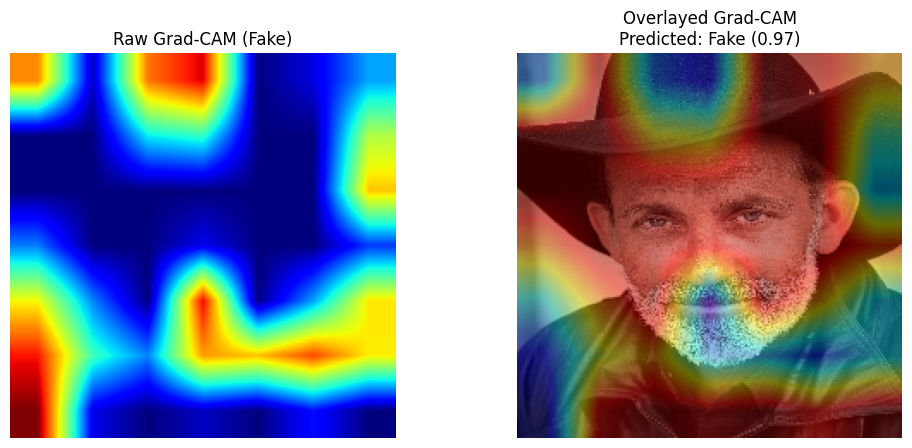

In [129]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- Function to create Grad-CAM heatmap ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps input to conv outputs + predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)

    # Normalize heatmap to 0-1 per image
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap) + 1e-8
    heatmap = heatmap.numpy()

    # Resize heatmap to match input image size (224x224)
    heatmap = cv2.resize(heatmap, (224,224))
    return heatmap, tf.argmax(predictions[0]).numpy()

# --- Function to overlay heatmap on original image ---
def overlay_heatmap(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    
    return img, superimposed_img

# --- External image path ---
external_img_path = "/kaggle/input/datasets/anetphilomina/test-image-real/people-875597_1280.jpg"  # replace with your image

# --- Load and preprocess ---
img = tf.keras.utils.load_img(external_img_path, target_size=(224,224))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# --- Choose earlier conv layer for better detail ---
last_conv_layer_name = "block_13_depthwise"  # higher resolution layer than last conv

# --- Generate Grad-CAM ---
heatmap, pred_class_idx = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
pred_class = "Real" if pred_class_idx==1 else "Fake"
pred_prob = model.predict(img_array)[0][pred_class_idx]

# --- Overlay ---
original_img, gradcam_img = overlay_heatmap(external_img_path, heatmap)

# --- Plot raw heatmap + overlay ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(heatmap, cmap='jet')
plt.axis('off')
plt.title(f"Raw Grad-CAM ({pred_class})")

plt.subplot(1,2,2)
plt.imshow(gradcam_img)
plt.axis('off')
plt.title(f"Overlayed Grad-CAM\nPredicted: {pred_class} ({pred_prob:.2f})")

plt.show()